# Brouillon 3 : quand la régression en niveaux est légitime (cointégration)

La partie 1 pourrait laisser croire qu'il faut *toujours* différencier. Ce n'est pas vrai : si deux séries
non stationnaires partagent la même tendance stochastique, elles sont **cointégrées** et la régression en
niveaux a un sens (relation de long terme). Test d'Engle-Granger : `coint` de statsmodels
(H0 : pas de cointégration).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

## 1. Simulation d'une paire cointégrée
Une tendance commune $w_t$ (marche aléatoire avec dérive), et deux séries qui la suivent avec un bruit stationnaire :
$x_t = w_t + u_t$, $y_t = 2 + 0.8\,w_t + v_t$.

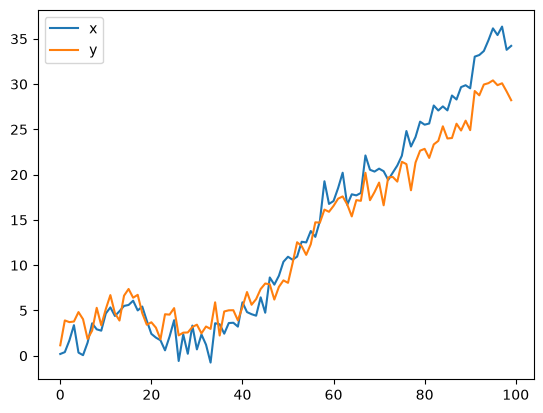

In [2]:
rng = np.random.default_rng(7)
n = 100
w = np.cumsum(0.5 + rng.normal(0, 1, n))
x = w + rng.normal(0, 1, n)
y = 2 + 0.8 * w + rng.normal(0, 1, n)

plt.plot(x, label="x")
plt.plot(y, label="y")
plt.legend()
plt.show()

Les deux séries sont non stationnaires (ADF) :

In [3]:
print(adfuller(x, regression="ct", result_object=False)[1], adfuller(y, regression="ct", result_object=False)[1])

0.8160724018224513 0.6740691202792017


## 2. Test d'Engle-Granger

In [4]:
resultat = coint(y, x)
resultat

CointResult(coint_t=-9.836488088794235, pvalue=6.425571726362188e-16, critical_values=array([-4.01048603, -3.39854434, -3.08756793]))

Pas de FutureWarning ici. p-value très faible : on rejette « pas de cointégration ».
Même test sur la paire fallacieuse de la partie 1 (seed 42) :

In [5]:
rng = np.random.default_rng(42)
xf = np.cumsum(0.5 + rng.normal(0, 1, n))
yf = np.cumsum(0.5 + rng.normal(0, 1, n))
coint(yf, xf)[1]

0.8182686937296701

On ne rejette pas : pas de cointégration, la régression en niveaux est fallacieuse. Le test distingue bien les deux cas.

## 3. Régression en niveaux et résidus

[1.957 0.799] R² = 0.983


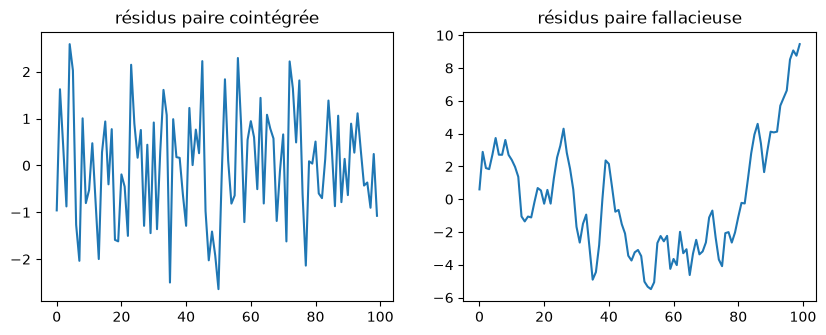

In [6]:
m = sm.OLS(y, sm.add_constant(x)).fit()
print(m.params.round(3), "R² =", round(m.rsquared, 3))
mf = sm.OLS(yf, sm.add_constant(xf)).fit()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(m.resid)
axes[0].set_title("résidus paire cointégrée")
axes[1].plot(mf.resid)
axes[1].set_title("résidus paire fallacieuse")
plt.show()

Pente ≈ 0.8 : on retrouve la vraie relation de long terme. (Le bruit sur x pourrait l'atténuer, mais il est
négligeable devant la variance de w qui grandit avec le temps : c'est la « super-convergence » de l'OLS en
cas de cointégration.) Les résidus de la paire cointégrée reviennent autour de 0, ceux de la paire fallacieuse
dérivent. C'est exactement ce que teste Engle-Granger (ADF sur les résidus).

## 4. Est-ce que le test est fiable ? Petit Monte Carlo
Taux de rejet à 5 % sur 300 paires cointégrées et 300 paires indépendantes.

In [7]:
def paire(rng, cointegree, n=100):
    if cointegree:
        w = np.cumsum(0.5 + rng.normal(0, 1, n))
        return w + rng.normal(0, 1, n), 2 + 0.8 * w + rng.normal(0, 1, n)
    return np.cumsum(0.5 + rng.normal(0, 1, n)), np.cumsum(0.5 + rng.normal(0, 1, n))

rng = np.random.default_rng(0)
for cointegree in [True, False]:
    pv = [coint(*paire(rng, cointegree)[::-1])[1] for _ in range(300)]
    print("cointégrées" if cointegree else "indépendantes", np.mean(np.array(pv) < 0.05) * 100, "%")

cointégrées 97.66666666666667 %


indépendantes 10.0 %


Le test détecte bien la cointégration (~98 %), mais sur les paires indépendantes il rejette ~10 % du temps
au lieu de 5 %. Hypothèse : les séries ont une dérive, alors que `coint` utilise par défaut `trend="c"`
(constante seulement). J'essaie `trend="ct"` (constante + tendance) :

In [8]:
rng = np.random.default_rng(0)
for cointegree in [True, False]:
    pv = [coint(*paire(rng, cointegree)[::-1], trend="ct")[1] for _ in range(300)]
    print("cointégrées" if cointegree else "indépendantes", np.mean(np.array(pv) < 0.05) * 100, "%")

cointégrées 95.66666666666667 %


indépendantes 8.0 %


Résultat ci-dessus à comparer. Et la paire de la partie 1 avec `trend="ct"` :

In [9]:
coint(yf, xf, trend="ct")[1], coint(y, x, trend="ct")[1]

(0.04705720876720114, 3.061542303140112e-15)

CONCLUSION_CT

## Bilan pour `src/`
- `simulation.py` : `simuler_paire_cointegree(n, derive, seed)`.
- `analyse.py` : `test_cointegration(y, x)` (p-value Engle-Granger), et un petit tableau comparatif
  paire fallacieuse / paire cointégrée.
- `graphiques.py` : figure 2×2 (séries en haut, résidus en bas) fallacieuse vs cointégrée.